In [1]:
import pyodbc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from future.backports.http.cookiejar import month

pd.set_option("display.max_rows", 1000)
from scipy.stats import t


conn = pyodbc.connect(f"DSN=PostgreSQL35W;UID=candidato")


Checando os nomes das tabelas e importando as tabelas para validação

In [2]:
cursor = conn.cursor()

query = "SELECT Distinct TABLE_NAME FROM information_schema.TABLES WHERE TABLE_NAME LIKE 'tb_%';"
cursor.execute(query)
print(cursor.fetchall())

[('tb_lojas',), ('tb_market_share',), ('tb_metas',), ('tb_produtos',), ('tb_vendas',)]


In [3]:
lojas = pd.read_sql("SELECT * FROM tb_lojas", conn)
lojas

C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\1452415181.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  lojas = pd.read_sql("SELECT * FROM tb_lojas", conn)


,id_loja,nome_loja,cidade,uf,canal
0,1,Supermercado Loja 1,Campinas,SP,Atacado
1,2,Supermercado Loja 2,Campinas,SP,Varejo
2,3,Supermercado Loja 3,Campinas,SP,Varejo
3,4,Supermercado Loja 4,Campinas,SP,Atacado
4,5,Supermercado Loja 5,Campinas,SP,Atacado
5,6,Supermercado Loja 6,Campinas,SP,Atacado
6,7,Supermercado Loja 7,Campinas,SP,Varejo
7,8,Supermercado Loja 8,Campinas,SP,Varejo
8,9,Supermercado Loja 9,Campinas,SP,Atacado
9,10,Supermercado Loja 10,Campinas,SP,Varejo


In [4]:
market_share = pd.read_sql("SELECT * FROM tb_market_share", conn)
market_share

C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\1486754884.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  market_share = pd.read_sql("SELECT * FROM tb_market_share", conn)


,id_share,data_referencia,categoria,volume_total_mercado
0,1,2024-01-01,Sorvetes,235173.35
1,2,2024-01-01,Chocolates,265632.97
2,3,2024-01-01,Bebidas,326928.98
3,4,2024-01-01,Mercearia,318890.35
4,5,2024-02-01,Sorvetes,472287.89
5,6,2024-02-01,Chocolates,390275.65
6,7,2024-02-01,Bebidas,393683.98
7,8,2024-02-01,Mercearia,490772.83
8,9,2024-03-01,Sorvetes,417400.77
9,10,2024-03-01,Chocolates,408616.95


In [5]:
metas = pd.read_sql("SELECT * FROM tb_metas", conn)
metas

C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\1419479431.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  metas = pd.read_sql("SELECT * FROM tb_metas", conn)


,id_meta,data_mes,id_loja,categoria,meta_valor
0,1,2024-01-01,1,Sorvetes,11667.35
1,2,2024-01-01,1,Chocolates,2980.13
2,3,2024-01-01,1,Bebidas,3550.28
3,4,2024-01-01,1,Mercearia,4861.25
4,5,2024-01-01,2,Sorvetes,8044.95
5,6,2024-01-01,2,Chocolates,2950.04
6,7,2024-01-01,2,Bebidas,4540.43
7,8,2024-01-01,2,Mercearia,4943.94
8,9,2024-01-01,3,Sorvetes,10294.28
9,10,2024-01-01,3,Chocolates,2890.32


In [6]:
produtos = pd.read_sql("SELECT * FROM tb_produtos", conn)
produtos

C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\2939446581.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  produtos = pd.read_sql("SELECT * FROM tb_produtos", conn)


,id_produto,nome_produto,categoria,marca
0,1,Sorvetes SKU 1,Sorvetes,Alpha
1,2,Sorvetes SKU 2,Sorvetes,Alpha
2,3,Sorvetes SKU 3,Sorvetes,Concorrente A
3,4,Sorvetes SKU 4,Sorvetes,Alpha
4,5,Sorvetes SKU 5,Sorvetes,Alpha
5,6,Chocolates SKU 1,Chocolates,Alpha
6,7,Chocolates SKU 2,Chocolates,Alpha
7,8,Chocolates SKU 3,Chocolates,Alpha
8,9,Chocolates SKU 4,Chocolates,Concorrente B
9,10,Chocolates SKU 5,Chocolates,Alpha


Vendas
Aparentemente há um erro de formatação decimal em alguma das colunas da tabela de vendas, provavelmente em valor_vendas

In [7]:
vendas = pd.read_sql("SELECT * FROM tb_vendas LIMIT 1", conn)
vendas

C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\1787168954.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vendas = pd.read_sql("SELECT * FROM tb_vendas LIMIT 1", conn)


,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda
0,1,2024-01-01,13,6,2,300.2


O problema são os valores ausentes (NaN) na coluna valor_venda.

In [8]:
vendas = pd.read_sql("SELECT id_venda, data_venda, id_produto, id_loja, qtd_vendida,valor_venda::text FROM tb_vendas", conn)
vendas['valor_venda'].str.contains("NaN").value_counts()


C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\31658424.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vendas = pd.read_sql("SELECT id_venda, data_venda, id_produto, id_loja, qtd_vendida,valor_venda::text FROM tb_vendas", conn)


valor_venda
False    18016
True       205
Name: count, dtype: int64

In [9]:
vendas = pd.read_sql("SELECT id_venda, data_venda, id_produto, id_loja, qtd_vendida, NULLIF(valor_venda, 'NaN') AS valor_venda FROM tb_vendas", conn)
vendas['valor_venda'].isna().value_counts()


C:\Users\ruffu\AppData\Local\Temp\ipykernel_17252\2413273568.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  vendas = pd.read_sql("SELECT id_venda, data_venda, id_produto, id_loja, qtd_vendida, NULLIF(valor_venda, 'NaN') AS valor_venda FROM tb_vendas", conn)


valor_venda
False    18016
True       205
Name: count, dtype: int64

Vou verificar se há um padrão nos preços que estão ausentes para poder fazer pensar em algum input de dados e para registrar se há algum viés na ausência de dados considerando lojas e produtos

In [10]:
vendas = pd.merge(vendas,produtos,on="id_produto")
vendas = pd.merge(vendas,lojas,on="id_loja")

In [11]:

teste = vendas[vendas['valor_venda'].isna()][['data_venda','id_loja','id_produto']].value_counts().reset_index()
teste
teste=teste.pivot_table(values='count',index='data_venda', columns='id_loja', aggfunc='sum')
k=teste.sum(axis=1,skipna=True)
k

data_venda
2024-01-05    1.0
2024-01-07    1.0
2024-01-08    2.0
2024-01-12    1.0
2024-01-21    1.0
2024-01-23    2.0
2024-01-25    1.0
2024-01-28    1.0
2024-01-31    1.0
2024-02-06    1.0
2024-02-08    1.0
2024-02-14    2.0
2024-02-15    1.0
2024-02-18    1.0
2024-02-19    1.0
2024-02-25    1.0
2024-03-01    2.0
2024-03-02    1.0
2024-03-04    1.0
2024-03-05    1.0
2024-03-07    2.0
2024-03-11    1.0
2024-03-13    1.0
2024-03-14    2.0
2024-03-20    2.0
2024-03-30    1.0
2024-03-31    1.0
2024-04-05    1.0
2024-04-11    2.0
2024-04-28    1.0
2024-05-01    1.0
2024-05-04    1.0
2024-05-09    1.0
2024-05-14    1.0
2024-05-19    1.0
2024-05-23    1.0
2024-05-25    2.0
2024-06-04    1.0
2024-06-21    1.0
2024-06-24    1.0
2024-06-27    1.0
2024-07-05    1.0
2024-07-07    1.0
2024-07-10    2.0
2024-07-11    1.0
2024-07-16    1.0
2024-07-17    1.0
2024-07-18    1.0
2024-07-19    1.0
2024-07-23    1.0
2024-07-24    1.0
2024-07-27    1.0
2024-07-28    2.0
2024-07-30    1.0
2024-08-04    1.0

In [12]:
teste = vendas.groupby('id_loja')['valor_venda'].apply(lambda x: x.isna().mean())
teste
#teste=teste.pivot_table(values='count',index='id_produto', columns='id_loja', aggfunc='sum')
#teste.sum(axis=0,skipna=True)


id_loja
1     0.012842
2     0.011538
3     0.012821
4     0.010899
5     0.014642
6     0.014215
7     0.007539
8     0.009285
9     0.010463
10    0.008315
Name: valor_venda, dtype: float64

In [13]:
teste = vendas.groupby('id_produto')['valor_venda'].apply(lambda x: x.isna().mean())
teste
#teste=teste.pivot_table(values='count',index='id_produto', columns='id_loja', aggfunc='sum')
#teste.sum(axis=0,skipna=True)


id_produto
1     0.011013
2     0.004386
3     0.011261
4     0.019715
5     0.012579
6     0.010870
7     0.009934
8     0.011312
9     0.013438
10    0.014739
11    0.010650
12    0.008979
13    0.004255
14    0.015784
15    0.008724
16    0.009454
17    0.009070
18    0.012155
19    0.019108
20    0.007726
Name: valor_venda, dtype: float64

In [14]:
teste = vendas[vendas['valor_venda'].isna()][['id_loja','id_produto']].value_counts().reset_index()
teste
teste=teste.pivot_table(values='count',index='id_produto', columns='id_loja', aggfunc='sum')
teste.sum(axis=1,skipna=True)


id_produto
1     10.0
2      4.0
3     10.0
4     18.0
5     12.0
6     10.0
7      9.0
8     10.0
9     12.0
10    13.0
11    10.0
12     8.0
13     4.0
14    14.0
15     8.0
16     9.0
17     8.0
18    11.0
19    18.0
20     7.0
dtype: float64

Não parece ter uma distribuição conentrada dos valores ausentes tanto em temros de produto como em termos de lojas. Vou desconsiderar os valores ausentes. Vou checar duplicações na tabela de vendas

In [15]:


vendas[vendas[['data_venda', 'id_loja','id_produto','qtd_vendida']].duplicated(keep=False)].sort_values(by=['data_venda','id_loja','id_produto','qtd_vendida'], ascending=False)


,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda,nome_produto,categoria,marca,nome_loja,cidade,uf,canal
4186,18164,2025-12-30,15,10,9,160.29,Bebidas SKU 5,Bebidas,Concorrente B,Supermercado Loja 10,Campinas,SP,Varejo
4187,18177,2025-12-30,15,10,9,89.75,Bebidas SKU 5,Bebidas,Concorrente B,Supermercado Loja 10,Campinas,SP,Varejo
4188,18182,2025-12-30,15,10,9,255.11,Bebidas SKU 5,Bebidas,Concorrente B,Supermercado Loja 10,Campinas,SP,Varejo
8266,18078,2025-12-27,4,1,11,357.19,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8267,18086,2025-12-27,4,1,11,417.91,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
17404,17975,2025-12-23,4,9,12,351.48,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 9,Campinas,SP,Atacado
17405,17978,2025-12-23,4,9,12,263.86,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 9,Campinas,SP,Atacado
9990,17980,2025-12-23,17,3,4,65.82,Mercearia SKU 2,Mercearia,Alpha,Supermercado Loja 3,Campinas,SP,Varejo
9991,17993,2025-12-23,17,3,4,213.78,Mercearia SKU 2,Mercearia,Alpha,Supermercado Loja 3,Campinas,SP,Varejo
6560,17962,2025-12-22,10,7,2,170.69,Chocolates SKU 5,Chocolates,Alpha,Supermercado Loja 7,Campinas,SP,Varejo


In [16]:
vendas[ (vendas['qtd_vendida']==11) & (vendas['id_loja']==1) & (vendas['id_produto']==4)].sort_values(by=['data_venda'], ascending=False)


,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda,nome_produto,categoria,marca,nome_loja,cidade,uf,canal
8266,18078,2025-12-27,4,1,11,357.19,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8267,18086,2025-12-27,4,1,11,417.91,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8231,10721,2025-03-04,4,1,11,436.30,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8230,10442,2025-02-21,4,1,11,348.13,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8224,8781,2024-12-15,4,1,11,218.70,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8192,1555,2024-03-04,4,1,11,236.81,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado
8186,72,2024-01-04,4,1,11,483.96,Sorvetes SKU 4,Sorvetes,Alpha,Supermercado Loja 1,Campinas,SP,Atacado


Existem entradas com mesma data, produto, loja e quantidade mas com os valores de venda bastante diferente. Apesar de achar que há uma variação estranaha nos valores unitários dos produtos (vendas virtualmente iguais no mesmo dia com valores de venda variando consideravelmente), essa variação parece ser comum nas vendas e pode refletir a natureza do dado. De qualquer forma não tenho como definir se há erro valores de venda dessas entradas que poderiam ser repetições. Vou fazer um teste de intervalo de confiança para vendas do mesmo produto na mesma loja, só para desencargo de checar se é possível identificar uma faixa de valor da venda associada ao produto que permita substituir os valores ausentes ou definir valores estranhos na repetição.

In [17]:


vendas['valor_unitario'] = vendas['valor_venda']/vendas['qtd_vendida']
var_prod = vendas.groupby(['id_produto', 'id_loja']).agg(
    media_valor=('valor_unitario', 'mean'),
    desvpad_valor=('valor_venda', 'std'),
    count=('qtd_vendida', 'count')
)
var_prod['interval_inf'] = var_prod['media_valor'] - t.ppf(0.975,var_prod['count']) * (var_prod['desvpad_valor']/np.sqrt(var_prod['count']))
var_prod['interval_sup'] = var_prod['media_valor'] + t.ppf(0.975,var_prod['count']) * (var_prod['desvpad_valor']/np.sqrt(var_prod['count']))
var_prod = var_prod.reset_index()
print(var_prod)

     id_produto  id_loja  media_valor  desvpad_valor  count  interval_inf   
0             1        1    58.660933     135.921116     70     26.259945  \
1             1        2    54.172570     131.116495     94     27.321078   
2             1        3    74.902627     132.638232     78     45.003444   
3             1        4    56.164990     126.083797     88     29.454666   
4             1        5    47.285625     118.810097    102     23.951881   
5             1        6    77.891451     138.907787     95     49.598372   
6             1        7    64.758831     132.595433     87     36.503543   
7             1        8    52.365323     120.165090     97     28.149882   
8             1        9    60.637380     141.039216    104     33.211906   
9             1       10    61.417402     144.677719     93     31.625647   
10            2        1    81.271701     138.612585     93     52.728867   
11            2        2    53.825771     143.659968     84     22.655135   

In [18]:
vendas['flag_valor_unitario'] = 0
vendas['interval_inf'] = 0
vendas['interval_sup'] = 0

for i in vendas.index:
    aux = var_prod[(var_prod['id_produto'] == vendas.loc[i]['id_produto']) & (var_prod['id_loja'] == vendas.loc[i]['id_loja'])]

    vendas.loc[i,'interval_inf'] = aux['interval_inf'].to_numpy('float64')

    vendas.loc[i,'interval_sup'] = aux['interval_sup'].to_numpy('float64')
    if ((vendas.loc[i]['valor_unitario'] > aux['interval_sup']) | (vendas.loc[i]['valor_unitario'] < aux['interval_inf'])).any():
        vendas.loc[i,'flag_valor_unitario'] = 1



In [19]:
vendas['flag_valor_unitario'].describe()

count    18221.000000
mean         0.662916
std          0.472727
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: flag_valor_unitario, dtype: float64

Os valores unitários não pareceram se enciaxar em intervalos de confiança considerando só o produto e a loja. Usar a data como variável de agrupamento para o intervalo de confiança pode reduzir muito os graus de liberdade dos intervalos. Vou assumir que não há duplicação e vou desconsiderar os valores ausentes

array([[<AxesSubplot:title={'center':'(1, 1)'}>,
        <AxesSubplot:title={'center':'(1, 2)'}>,
        <AxesSubplot:title={'center':'(1, 3)'}>,
        <AxesSubplot:title={'center':'(1, 4)'}>,
        <AxesSubplot:title={'center':'(1, 5)'}>,
        <AxesSubplot:title={'center':'(1, 6)'}>,
        <AxesSubplot:title={'center':'(1, 7)'}>,
        <AxesSubplot:title={'center':'(1, 8)'}>,
        <AxesSubplot:title={'center':'(1, 9)'}>,
        <AxesSubplot:title={'center':'(1, 10)'}>,
        <AxesSubplot:title={'center':'(1, 11)'}>,
        <AxesSubplot:title={'center':'(1, 12)'}>,
        <AxesSubplot:title={'center':'(1, 13)'}>,
        <AxesSubplot:title={'center':'(1, 14)'}>],
       [<AxesSubplot:title={'center':'(1, 15)'}>,
        <AxesSubplot:title={'center':'(1, 16)'}>,
        <AxesSubplot:title={'center':'(1, 17)'}>,
        <AxesSubplot:title={'center':'(1, 18)'}>,
        <AxesSubplot:title={'center':'(1, 19)'}>,
        <AxesSubplot:title={'center':'(1, 20)'}>,
        

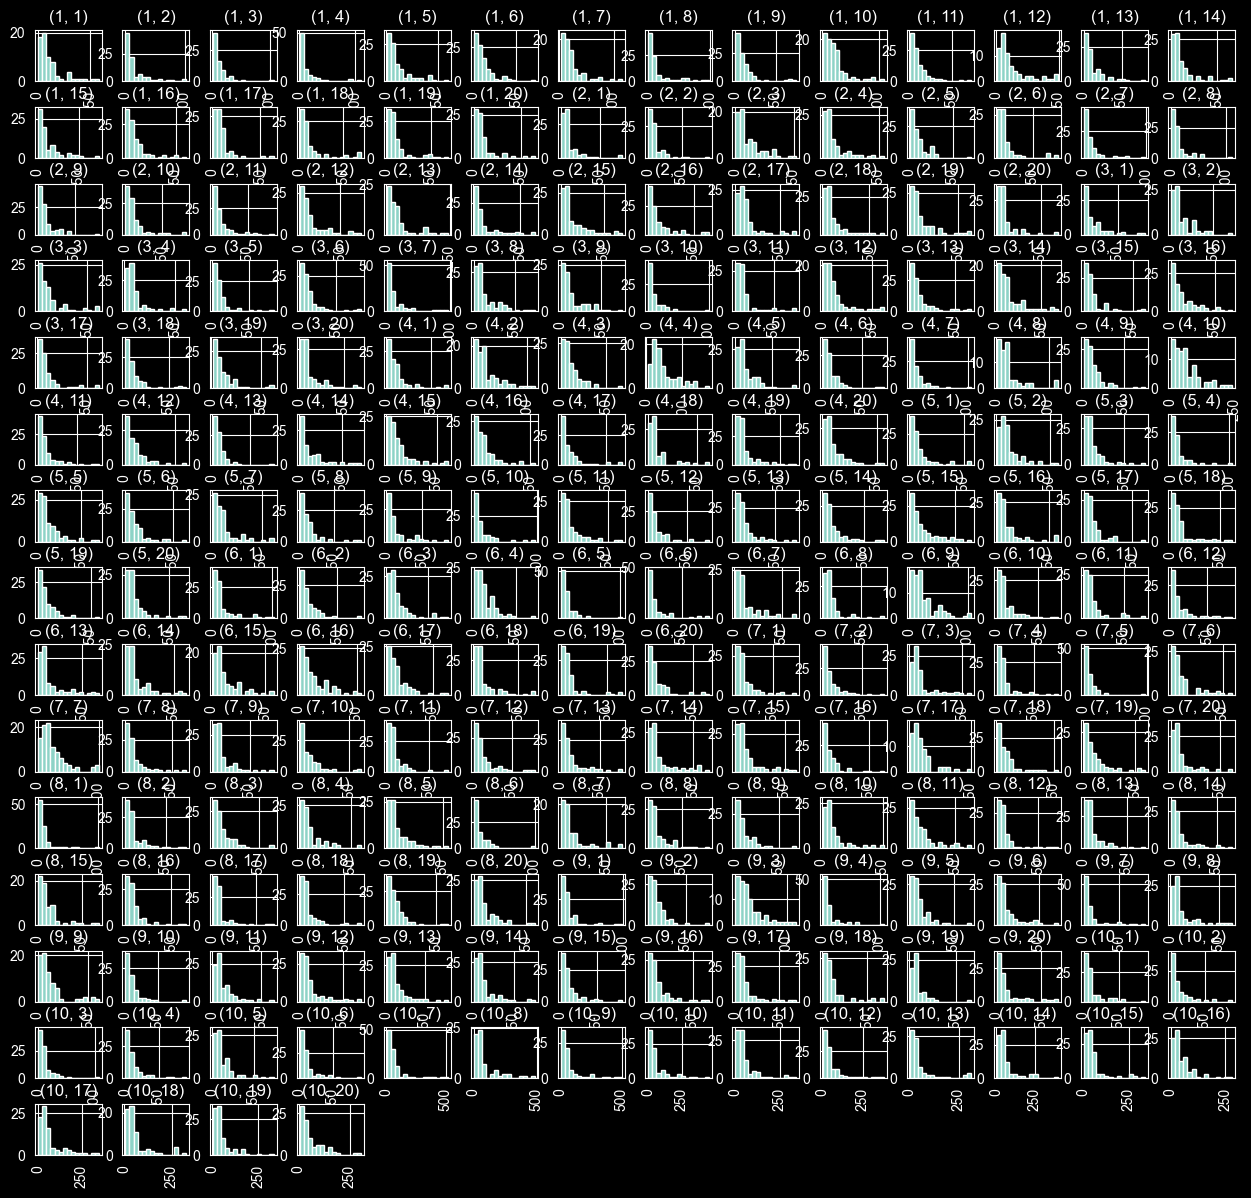

In [20]:
vendas.hist(column='valor_unitario', by=['id_loja','id_produto'], bins=15,figsize=(15,15),grid=True,)

In [21]:
vendas[vendas[['data_venda','id_produto','id_loja','qtd_vendida','valor_venda']].duplicated(keep=False)].sort_values(by=['data_venda'], ascending=False)


,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda,nome_produto,categoria,marca,nome_loja,cidade,uf,canal,valor_unitario,flag_valor_unitario,interval_inf,interval_sup


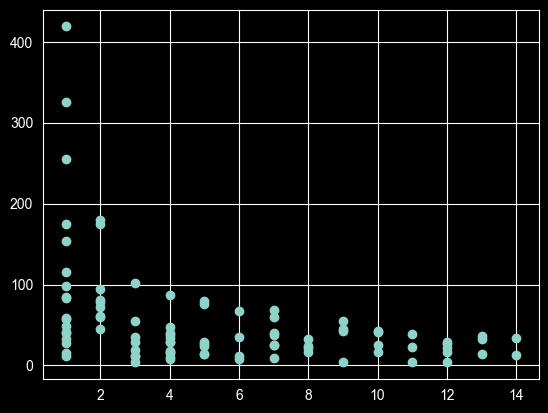

In [22]:
plt.scatter(vendas[(vendas['id_produto']==5) & (vendas['id_loja']==3)]['qtd_vendida'], vendas[(vendas['id_produto']==5) & (vendas['id_loja']==3)]['valor_unitario'])


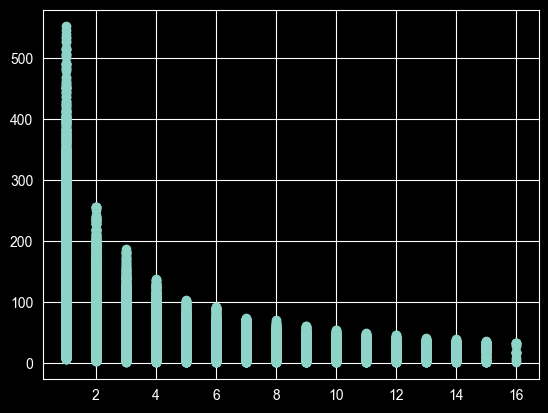

In [23]:
plt.scatter(vendas['qtd_vendida'], vendas['valor_unitario'],)


In [24]:
vendas

,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda,nome_produto,categoria,marca,nome_loja,cidade,uf,canal,valor_unitario,flag_valor_unitario,interval_inf,interval_sup
0,1,2024-01-01,13,6,2,300.20,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,150.100000,1,46.374053,90.489867
1,304,2024-01-12,13,6,9,98.80,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,10.977778,1,46.374053,90.489867
2,364,2024-01-14,13,6,3,198.71,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,66.236667,0,46.374053,90.489867
3,489,2024-01-20,13,6,9,155.70,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,17.300000,1,46.374053,90.489867
4,627,2024-01-25,13,6,6,184.06,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,30.676667,1,46.374053,90.489867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18216,17549,2025-12-06,20,9,10,183.61,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,18.361000,1,41.857300,84.331281
18217,17729,2025-12-13,20,9,3,290.80,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,96.933333,1,41.857300,84.331281
18218,17749,2025-12-14,20,9,5,96.94,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,19.388000,1,41.857300,84.331281
18219,17827,2025-12-16,20,9,3,267.92,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,89.306667,1,41.857300,84.331281


In [25]:
vendas

,id_venda,data_venda,id_produto,id_loja,qtd_vendida,valor_venda,nome_produto,categoria,marca,nome_loja,cidade,uf,canal,valor_unitario,flag_valor_unitario,interval_inf,interval_sup
0,1,2024-01-01,13,6,2,300.20,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,150.100000,1,46.374053,90.489867
1,304,2024-01-12,13,6,9,98.80,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,10.977778,1,46.374053,90.489867
2,364,2024-01-14,13,6,3,198.71,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,66.236667,0,46.374053,90.489867
3,489,2024-01-20,13,6,9,155.70,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,17.300000,1,46.374053,90.489867
4,627,2024-01-25,13,6,6,184.06,Bebidas SKU 3,Bebidas,Alpha,Supermercado Loja 6,Campinas,SP,Atacado,30.676667,1,46.374053,90.489867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18216,17549,2025-12-06,20,9,10,183.61,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,18.361000,1,41.857300,84.331281
18217,17729,2025-12-13,20,9,3,290.80,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,96.933333,1,41.857300,84.331281
18218,17749,2025-12-14,20,9,5,96.94,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,19.388000,1,41.857300,84.331281
18219,17827,2025-12-16,20,9,3,267.92,Mercearia SKU 5,Mercearia,Concorrente B,Supermercado Loja 9,Campinas,SP,Atacado,89.306667,1,41.857300,84.331281


<__array_function__ internals>:200: UserWarning: Warning: converting a masked element to nan.
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\colors.py:1211: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\ticker.py:548: UserWarning: Warning: converting a masked element to nan.
  if self._useLocale else fmt % arg)


<AxesSubplot:>

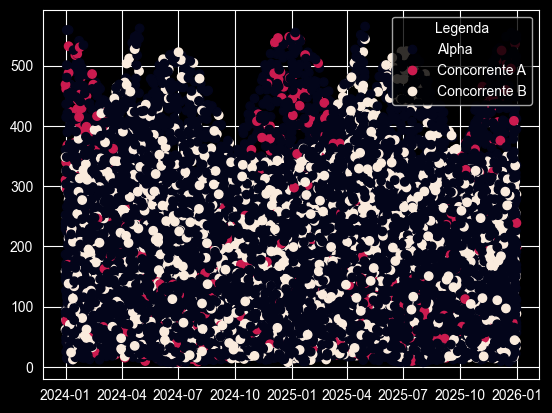

In [26]:




levels, categories = pd.factorize(vendas['marca'])
scatter =plt.scatter(vendas['data_venda'], vendas['valor_venda'],c=levels)
plt.legend(scatter.legend_elements()[0], categories, title='Legenda')
plt.gca()


<__array_function__ internals>:200: UserWarning: Warning: converting a masked element to nan.
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\colors.py:1211: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\ticker.py:548: UserWarning: Warning: converting a masked element to nan.
  if self._useLocale else fmt % arg)


<AxesSubplot:>

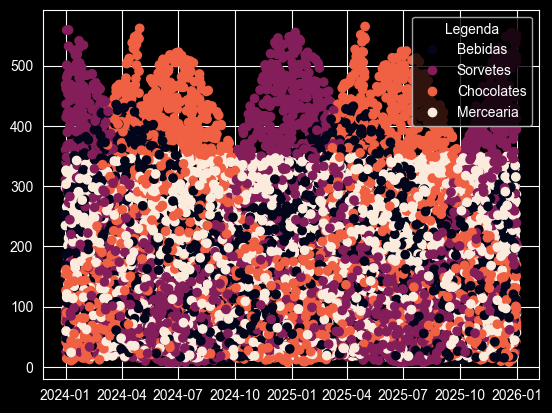

In [27]:




levels, categories = pd.factorize(vendas['categoria'])
scatter =plt.scatter(vendas['data_venda'], vendas['valor_venda'],c=levels)
plt.legend(scatter.legend_elements()[0], categories, title='Legenda')
plt.gca()


<__array_function__ internals>:200: UserWarning: Warning: converting a masked element to nan.
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\colors.py:1211: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
C:\Users\ruffu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\matplotlib\ticker.py:548: UserWarning: Warning: converting a masked element to nan.
  if self._useLocale else fmt % arg)


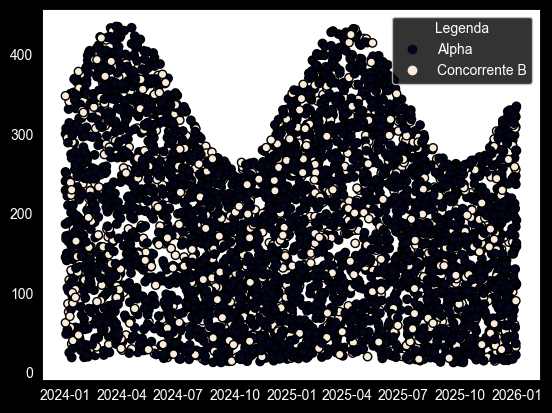

In [28]:


teste = vendas[vendas['categoria']=="Bebidas"]

levels, categories = pd.factorize(teste['marca'])
scatter =plt.scatter(teste['data_venda'], teste['valor_venda'],c=levels,edgecolors='black',facecolors='none')
plt.legend(scatter.legend_elements()[0], categories, title='Legenda')

plt.gca().set_facecolor('white')


O approach anterior não tinha considerado a sazonalidade dos dados. Agora sabemos que os diferentes produtos tem sazonalidades diferentes (e a analise de intervalos de confiança anterior não dava conta disso). Vou fazer mais alguns testes, e acho que deverá ser possível imputar dados com modelos lineares considerando um mmodelo para cada categoria

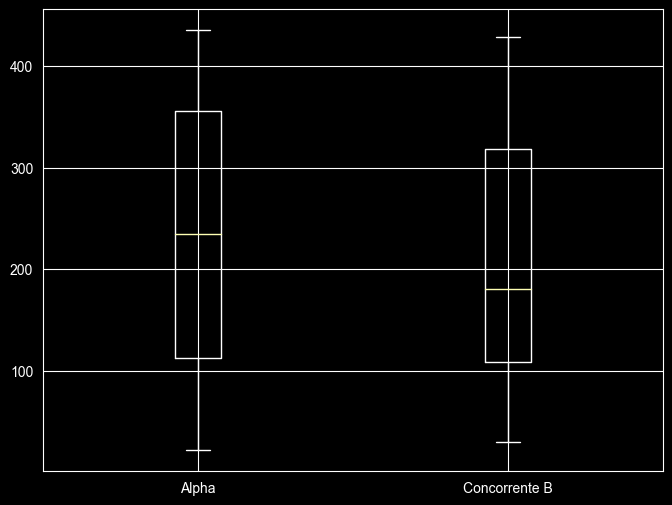

In [29]:


teste = vendas[(vendas['categoria']=="Bebidas") &  (pd.to_datetime(vendas['data_venda']).between('2024-03-01','2024-03-31'))]
teste = teste[teste['valor_venda'].isna()==False]
grouped_teste = teste.groupby('marca')['valor_venda']
fig, ax = plt.subplots(figsize=(8,6))
ax.boxplot(x=[group.values for name, group in grouped_teste],
           labels=grouped_teste.groups.keys())

plt.show()

A conclusão da análise é que os dados faltantes não podem ser modelados por modelos lineares, mas que as variações dos preços, a depender da categoria, estão envelopadas em distribuições variando temporalmente. Não consegui identificar outras dependencias do valor que indicassem


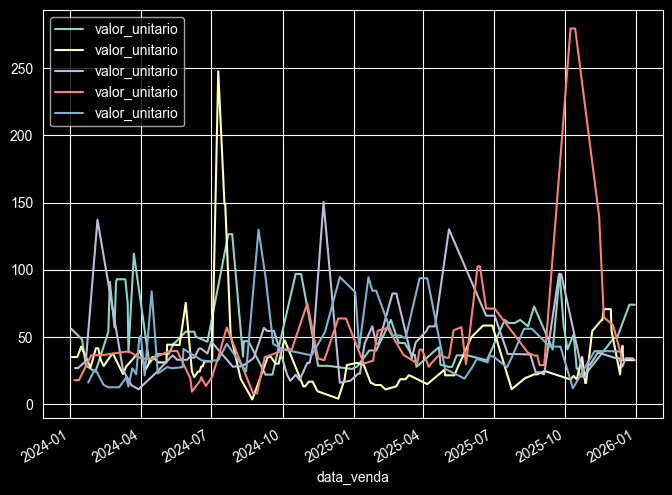

In [30]:
vendas['data_venda'] = pd.to_datetime(vendas['data_venda'])

p= vendas[['data_venda','valor_venda','nome_produto','categoria','marca','nome_loja','canal']].sort_values(by=['nome_produto','categoria','marca','nome_loja','canal','data_venda']).groupby(['nome_produto','categoria','marca','nome_loja','canal']).rolling(window="30D",center=True, on='data_venda')['valor_venda'].median().reset_index()
p = p[(p['categoria']=='Chocolates')  & (p['canal']=='Atacado') & (p['nome_loja']=='Supermercado Loja 9')]

fig, ax = plt.subplots(figsize=(8,6))
bp = p.groupby(['nome_produto','categoria','marca','nome_loja','canal']).plot('data_venda','valor_venda', ax=ax)





Usei esse ultimo gráfico para verificar se o uso de uma medianas móvel pode ser uma ferramenta razoável para imputar dados, considerando se ela  consegue acompanhar as curvas sazoanais e ainda mostrar alugma distinção considerando variáveis que precisam ser comparadas (marca, produto, loja, canal, categoria). Um período de 30 dias pareceu ser um bom equilibrio, levando em conta que os dados ficam mais esparsos ao criarmos curvas de medianas móveis próprias para cada combinação de características. A ideia é que os valores imputados sejam uma estimativa plausível das transações do período.

No próprio PBI validei o intervalo de dias da janela que produzia a menor distancia de erro entre o imputado e os valores reais - cheguei no valor de 33 dias.